In [ ]:
import pandas as pd
import numpy as np
from fredapi import Fred
import matplotlib.pyplot as plt
import os
from fredapi import Fred
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.api import VAR

os.makedirs("output/figures", exist_ok=True)

# --- API setup ---

import os
os.environ["FRED_API_KEY"] = "YOUR_FRED_API_KEY_HERE"  # Replace with your actual FRED API key

api_key = os.getenv("FRED_API_KEY")
if api_key is None:
    raise ValueError("Set the FRED_API_KEY environment variable before running this notebook.")

fred = Fred(api_key=api_key)

# --- Series to pull ---
series_ids = {
    'y_3M':  'DGS3MO',
    'y_2Y':  'DGS2',
    'y_5Y':  'DGS5',
    'y_10Y': 'DGS10',
    'y_30Y': 'DGS30',
    'FFR':   'FEDFUNDS',
}

# --- Pull each series ---
raw = {}
for name, fred_id in series_ids.items():
    raw[name] = fred.get_series(
        fred_id,
        observation_start='1999-01-01',  # pull a bit early to allow lookback
        observation_end='2025-12-31'
    )
    print(f"{name} ({fred_id}): {len(raw[name])} observations, "
          f"from {raw[name].index.min().date()} to {raw[name].index.max().date()}")

# --- Combine into a daily DataFrame ---
df_daily = pd.DataFrame(raw)
print("\nDaily DataFrame shape:", df_daily.shape)
print(df_daily.head())
print(df_daily.tail())

y_3M (DGS3MO): 7044 observations, from 1999-01-01 to 2025-12-31
y_2Y (DGS2): 7044 observations, from 1999-01-01 to 2025-12-31
y_5Y (DGS5): 7044 observations, from 1999-01-01 to 2025-12-31
y_10Y (DGS10): 7044 observations, from 1999-01-01 to 2025-12-31
y_30Y (DGS30): 7044 observations, from 1999-01-01 to 2025-12-31
FFR (FEDFUNDS): 324 observations, from 1999-01-01 to 2025-12-01

Daily DataFrame shape: (7136, 6)
            y_3M  y_2Y  y_5Y  y_10Y  y_30Y   FFR
1999-01-01   NaN   NaN   NaN    NaN    NaN  4.63
1999-01-04  4.49  4.58  4.57   4.69   5.15   NaN
1999-01-05  4.48  4.64  4.62   4.74   5.21   NaN
1999-01-06  4.47  4.62  4.61   4.73   5.17   NaN
1999-01-07  4.44  4.63  4.62   4.77   5.23   NaN
            y_3M  y_2Y  y_5Y  y_10Y  y_30Y  FFR
2025-12-25   NaN   NaN   NaN    NaN    NaN  NaN
2025-12-26  3.64  3.46  3.68   4.14   4.81  NaN
2025-12-29  3.68  3.45  3.67   4.12   4.80  NaN
2025-12-30  3.65  3.45  3.68   4.14   4.81  NaN
2025-12-31  3.67  3.47  3.73   4.18   4.84  NaN


In [99]:
# --- Resample yields to monthly (end-of-month) ---
# For yields, take the last available observation in each month
yields_monthly = df_daily[['y_3M', 'y_2Y', 'y_5Y', 'y_10Y', 'y_30Y']].resample('ME').last()

# --- FFR is already monthly, but indexed on month-start; align to month-end ---
ffr_monthly = df_daily['FFR'].resample('ME').last()

# --- Combine ---
df = pd.concat([yields_monthly, ffr_monthly], axis=1)

# --- Restrict to our analysis sample: 2000-01 to 2025-12 ---
df = df.loc['2000-01-01':'2025-12-31']

# --- Convert from percent to decimal (e.g., 4.50 -> 0.045) ---
# Important for return calculations later
df = df / 100

# --- Inspect ---
print("Monthly DataFrame shape:", df.shape)
print("\nDate range:", df.index.min().date(), "to", df.index.max().date())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

Monthly DataFrame shape: (312, 6)

Date range: 2000-01-31 to 2025-12-31

Missing values per column:
y_3M     0
y_2Y     0
y_5Y     0
y_10Y    0
y_30Y    0
FFR      0
dtype: int64

First 5 rows:
              y_3M    y_2Y    y_5Y   y_10Y   y_30Y     FFR
2000-01-31  0.0576  0.0661  0.0671  0.0668  0.0649  0.0545
2000-02-29  0.0578  0.0653  0.0661  0.0642  0.0615  0.0573
2000-03-31  0.0588  0.0650  0.0632  0.0603  0.0584  0.0585
2000-04-30  0.0582  0.0668  0.0656  0.0623  0.0597  0.0602
2000-05-31  0.0563  0.0669  0.0654  0.0629  0.0602  0.0627

Last 5 rows:
              y_3M    y_2Y    y_5Y   y_10Y   y_30Y     FFR
2025-08-31  0.0423  0.0359  0.0368  0.0423  0.0492  0.0433
2025-09-30  0.0402  0.0360  0.0374  0.0416  0.0473  0.0422
2025-10-31  0.0389  0.0360  0.0371  0.0411  0.0467  0.0409
2025-11-30  0.0388  0.0347  0.0359  0.0402  0.0467  0.0388
2025-12-31  0.0367  0.0347  0.0373  0.0418  0.0484  0.0372


In [100]:
# --- Nelson-Siegel proxies (Diebold-Li 2006) ---
df['L'] = df['y_10Y']                                          # Level
df['S'] = df['y_10Y'] - df['y_3M']                             # Slope
df['C'] = 2 * df['y_2Y'] - df['y_3M'] - df['y_10Y']            # Curvature

# --- Regime classifier from FFR direction ---
# Trailing 6-month change in FFR
df['dFFR_6m'] = df['FFR'] - df['FFR'].shift(6)

# Threshold: ±25 bps = ±0.0025 in decimals
threshold = 0.0025

def classify(d):
    if pd.isna(d):
        return np.nan
    elif d > threshold:
        return 'tightening'
    elif d < -threshold:
        return 'easing'
    else:
        return 'neutral'

df['regime'] = df['dFFR_6m'].apply(classify)

# --- Inspect ---
print("Sample of new variables (mid-sample):")
print(df[['y_10Y', 'L', 'S', 'C', 'FFR', 'dFFR_6m', 'regime']].loc['2007-01-31':'2008-12-31'])

print("\nRegime counts:")
print(df['regime'].value_counts(dropna=False))

print("\nFraction in each regime:")
print(df['regime'].value_counts(normalize=True, dropna=False))

Sample of new variables (mid-sample):
             y_10Y       L       S       C     FFR  dFFR_6m   regime
2007-01-31  0.0483  0.0483 -0.0029 -0.0007  0.0525   0.0001  neutral
2007-02-28  0.0456  0.0456 -0.0060 -0.0042  0.0526   0.0001  neutral
2007-03-31  0.0465  0.0465 -0.0039 -0.0053  0.0526   0.0001  neutral
2007-04-30  0.0463  0.0463 -0.0028 -0.0034  0.0525   0.0000  neutral
2007-05-31  0.0490  0.0490  0.0017  0.0021  0.0525   0.0000  neutral
2007-06-30  0.0503  0.0503  0.0021 -0.0011  0.0525   0.0001  neutral
2007-07-31  0.0478  0.0478 -0.0018 -0.0062  0.0526   0.0001  neutral
2007-08-31  0.0454  0.0454  0.0053 -0.0025  0.0502  -0.0024  neutral
2007-09-30  0.0459  0.0459  0.0077 -0.0047  0.0494  -0.0032   easing
2007-10-31  0.0448  0.0448  0.0054 -0.0054  0.0476  -0.0049   easing
2007-11-30  0.0397  0.0397  0.0082 -0.0104  0.0449  -0.0076   easing
2007-12-31  0.0404  0.0404  0.0068 -0.0130  0.0424  -0.0101   easing
2008-01-31  0.0367  0.0367  0.0171 -0.0129  0.0394  -0.0132   eas

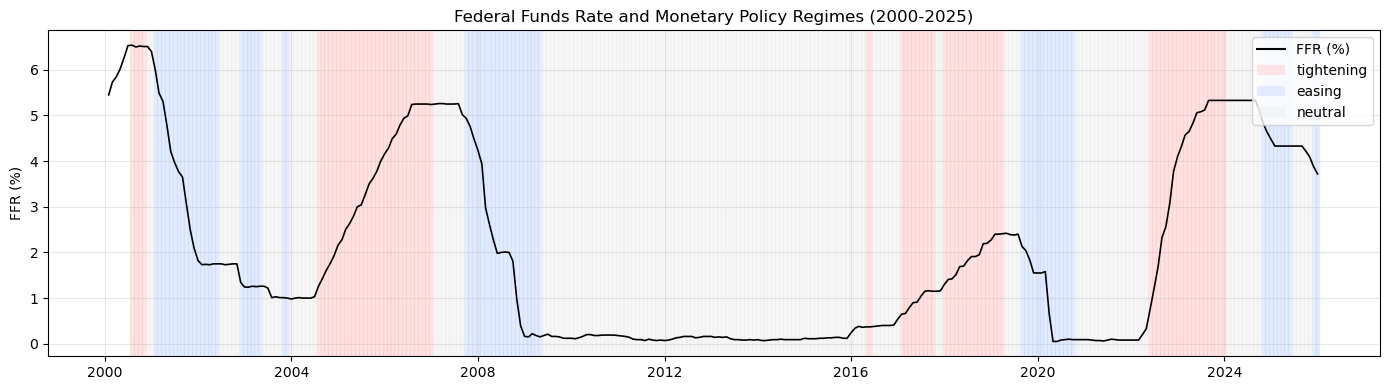

In [101]:
# --- Plot regimes over time ---
fig, ax = plt.subplots(figsize=(14, 4))

# Plot FFR
ax.plot(df.index, df['FFR'] * 100, color='black', linewidth=1.2, label='FFR (%)')

# Color-shade by regime
regime_colors = {'tightening': '#ffcccc', 'easing': '#ccddff', 'neutral': '#f0f0f0'}
for regime, color in regime_colors.items():
    mask = df['regime'] == regime
    for date in df.index[mask]:
        ax.axvspan(date - pd.Timedelta(days=15), date + pd.Timedelta(days=15), 
                   color=color, alpha=0.5, zorder=0)

ax.set_title('Federal Funds Rate and Monetary Policy Regimes (2000-2025)')
ax.set_ylabel('FFR (%)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Custom legend for regimes
from matplotlib.patches import Patch
regime_legend = [Patch(facecolor=c, alpha=0.5, label=r) 
                 for r, c in regime_colors.items()]
ax.legend(handles=[plt.Line2D([0], [0], color='black', label='FFR (%)')] + regime_legend,
          loc='upper right')

plt.tight_layout()
plt.savefig('output/figures/regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# --- Excess returns using modified duration approximation ---
# Modified duration for a par coupon bond: D_mod = (1 - (1+y)^(-n)) / y

maturities = {'2Y': 2, '5Y': 5, '10Y': 10, '30Y': 30}

for label, n in maturities.items():
    y = df[f'y_{label}']
    y_short = df['y_3M']
    
    # Modified duration (computed from current yield)
    D_mod = (1 - (1 + y) ** (-n)) / y
    
    # Carry: 1/12 of annual yield
    carry = y / 12
    
    # Capital gain/loss: -modified_duration × yield change
    capital = -D_mod * (y.shift(-1) - y)
    
    # Total return next month
    total_return = carry + capital
    
    # Excess return: subtract 1-month risk-free rate (proxied by 3M/12)
    df[f'rx_{label}'] = total_return - y_short / 12

# --- Inspect ---
print("Excess returns summary (annualized, in %):")
for label in maturities.keys():
    series = df[f'rx_{label}'].dropna() * 12 * 100
    print(f"  {label}: mean = {series.mean():>6.2f}%, "
          f"std = {series.std():>6.2f}%, "
          f"obs = {len(series)}")

print("\nFirst few excess returns:")
print(df[['rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].head())

print("\nLast few excess returns:")
print(df[['rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].tail())

Excess returns summary (annualized, in %):
  2Y: mean =   0.52%, std =   5.63%, obs = 311
  5Y: mean =   1.25%, std =  14.92%, obs = 311
  10Y: mean =   1.92%, std =  26.11%, obs = 311
  30Y: mean =   2.16%, std =  49.86%, obs = 311

First few excess returns:
               rx_2Y     rx_5Y    rx_10Y    rx_30Y
2000-01-31  0.002163  0.004924  0.019301  0.045054
2000-02-29  0.001171  0.012707  0.028675  0.042303
2000-03-31 -0.002760 -0.009656 -0.014574 -0.018238
2000-04-30  0.000535  0.001446 -0.004027 -0.006780
2000-05-31  0.006512  0.015703  0.019426  0.016808

Last few excess returns:
               rx_2Y     rx_5Y    rx_10Y    rx_30Y
2025-08-31 -0.000723 -0.003154  0.005613  0.030051
2025-09-30 -0.000350  0.001112  0.004140  0.010106
2025-10-31  0.002224  0.005236  0.007443  0.000650
2025-11-30 -0.000342 -0.006547 -0.012848 -0.026487
2025-12-31       NaN       NaN       NaN       NaN


In [103]:
# --- Excess returns by regime ---
print("Mean annualized excess returns by regime (%):\n")

regime_summary = df.groupby('regime')[['rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].agg(['mean', 'std', 'count'])
# Annualize means (×12) and convert to percent
for col in ['rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']:
    regime_summary[(col, 'mean')] = regime_summary[(col, 'mean')] * 12 * 100
    regime_summary[(col, 'std')] = regime_summary[(col, 'std')] * np.sqrt(12) * 100

print(regime_summary.round(2))

# --- Sharpe ratios by regime ---
print("\nAnnualized Sharpe ratio by regime:\n")
sharpes = pd.DataFrame(index=df['regime'].dropna().unique())
for col in ['rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']:
    for regime in sharpes.index:
        sub = df.loc[df['regime'] == regime, col].dropna()
        sharpes.loc[regime, col] = (sub.mean() * 12) / (sub.std() * np.sqrt(12))
print(sharpes.round(2))

Mean annualized excess returns by regime (%):

           rx_2Y             rx_5Y             rx_10Y             rx_30Y  \
            mean   std count  mean   std count   mean   std count   mean   
regime                                                                     
easing      2.81  2.00    68  4.84  4.76    68   5.53  8.58    68   3.92   
neutral     0.19  1.42   156  0.54  4.25   156   1.28  7.42   156   2.18   
tightening -0.88  1.54    81 -0.68  3.99    81  -0.44  6.91    81  -0.62   

                         
              std count  
regime                   
easing      17.16    68  
neutral     13.98   156  
tightening  13.05    81  

Annualized Sharpe ratio by regime:

            rx_2Y  rx_5Y  rx_10Y  rx_30Y
tightening  -0.57  -0.17   -0.06   -0.05
neutral      0.14   0.13    0.17    0.16
easing       1.41   1.02    0.64    0.23


In [104]:

# --- Build regression dataset ---
# Drop NaN rows (first 6 months from regime lookback, last month from forward return)
reg_df = df[['L', 'S', 'C', 'regime', 'rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].dropna()
print(f"Regression sample: {len(reg_df)} observations")
print(f"Regime distribution in regression sample:")
print(reg_df['regime'].value_counts())

# --- Create regime dummies ---
# Drop 'neutral' as the baseline category (so coefficients on dummies = effect relative to neutral)
reg_df = pd.get_dummies(reg_df, columns=['regime'], drop_first=False, dtype=float)
reg_df = reg_df.drop(columns=['regime_neutral'])  # neutral is baseline

# --- Create interactions: NS factors × regime dummies ---
for factor in ['L', 'S', 'C']:
    for regime in ['easing', 'tightening']:
        reg_df[f'{factor}_x_{regime}'] = reg_df[factor] * reg_df[f'regime_{regime}']

# --- Helper function to run one regression ---
def run_regression(y_col, X_cols, df=reg_df, hac_lags=3):
    y = df[y_col]
    X = add_constant(df[X_cols])
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    return model

# --- Run baseline (no regime interactions) for each maturity ---
print("\n" + "="*80)
print("BASELINE: Excess returns on NS factors only")
print("="*80)

baseline_X = ['L', 'S', 'C']
baseline_results = {}
for mat in ['2Y', '5Y', '10Y', '30Y']:
    m = run_regression(f'rx_{mat}', baseline_X)
    baseline_results[mat] = m
    print(f"\n--- rx_{mat} ---")
    print(f"R² = {m.rsquared:.3f}")
    for var, coef, pval in zip(['const'] + baseline_X, m.params, m.pvalues):
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"  {var:>10}: {coef:>10.4f}  (p={pval:.3f}) {sig}")

Regression sample: 305 observations
Regime distribution in regression sample:
regime
neutral       156
tightening     81
easing         68
Name: count, dtype: int64

BASELINE: Excess returns on NS factors only

--- rx_2Y ---
R² = 0.041
       const:    -0.0025  (p=0.025) **
           L:     0.0737  (p=0.006) ***
           S:     0.0085  (p=0.804) 
           C:    -0.0473  (p=0.382) 

--- rx_5Y ---
R² = 0.039
       const:    -0.0064  (p=0.015) **
           L:     0.1766  (p=0.003) ***
           S:     0.0962  (p=0.191) 
           C:    -0.0378  (p=0.769) 

--- rx_10Y ---
R² = 0.038
       const:    -0.0107  (p=0.017) **
           L:     0.2650  (p=0.008) ***
           S:     0.1736  (p=0.136) 
           C:    -0.1483  (p=0.491) 

--- rx_30Y ---
R² = 0.033
       const:    -0.0185  (p=0.035) **
           L:     0.3877  (p=0.043) **
           S:     0.2437  (p=0.264) 
           C:    -0.5141  (p=0.213) 


In [105]:
# --- With regime interactions ---
print("\n" + "="*80)
print("WITH REGIME INTERACTIONS")
print("="*80)

interaction_X = (
    ['L', 'S', 'C'] +
    ['regime_easing', 'regime_tightening'] +
    [f'{f}_x_{r}' for f in ['L', 'S', 'C'] for r in ['easing', 'tightening']]
)

regime_results = {}
for mat in ['2Y', '5Y', '10Y', '30Y']:
    m = run_regression(f'rx_{mat}', interaction_X)
    regime_results[mat] = m
    print(f"\n--- rx_{mat} ---")
    print(f"R² = {m.rsquared:.3f}  (baseline R² = {baseline_results[mat].rsquared:.3f})")
    for var, coef, pval in zip(['const'] + interaction_X, m.params, m.pvalues):
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"  {var:>22}: {coef:>10.4f}  (p={pval:.3f}) {sig}")
    
    # Joint test: are all regime coefficients (dummies + interactions) jointly zero?
    regime_vars = [v for v in interaction_X if 'regime' in v or '_x_' in v]
    f_test = m.f_test(' = '.join(regime_vars) + ' = 0')
    print(f"  Joint F-test (all regime terms = 0): F = {f_test.fvalue:.2f}, p = {f_test.pvalue:.4f}")


WITH REGIME INTERACTIONS

--- rx_2Y ---
R² = 0.096  (baseline R² = 0.041)
                   const:    -0.0025  (p=0.060) *
                       L:     0.0911  (p=0.010) **
                       S:     0.0010  (p=0.984) 
                       C:    -0.0076  (p=0.931) 
           regime_easing:     0.0039  (p=0.067) *
       regime_tightening:    -0.0015  (p=0.547) 
              L_x_easing:    -0.0354  (p=0.517) 
          L_x_tightening:    -0.0057  (p=0.925) 
              S_x_easing:     0.0046  (p=0.953) 
          S_x_tightening:     0.0231  (p=0.747) 
              C_x_easing:     0.1419  (p=0.261) 
          C_x_tightening:    -0.0576  (p=0.750) 
  Joint F-test (all regime terms = 0): F = 2.04, p = 0.0415

--- rx_5Y ---
R² = 0.060  (baseline R² = 0.039)
                   const:    -0.0078  (p=0.021) **
                       L:     0.2329  (p=0.004) ***
                       S:     0.1018  (p=0.356) 
                       C:     0.0170  (p=0.942) 
           regime_easin

In [106]:
# Regime-only specification (no NS factors)
print("\n" + "="*80)
print("REGIME-ONLY SPECIFICATION")
print("="*80)

regime_only_X = ['regime_easing', 'regime_tightening']
for mat in ['2Y', '5Y', '10Y', '30Y']:
    m = run_regression(f'rx_{mat}', regime_only_X)
    print(f"\n--- rx_{mat} ---")
    print(f"R² = {m.rsquared:.3f}")
    for var, coef, pval in zip(['const'] + regime_only_X, m.params, m.pvalues):
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"  {var:>22}: {coef:>10.4f}  (p={pval:.3f}) {sig}")


REGIME-ONLY SPECIFICATION

--- rx_2Y ---
R² = 0.055
                   const:     0.0002  (p=0.650) 
           regime_easing:     0.0022  (p=0.008) ***
       regime_tightening:    -0.0009  (p=0.137) 

--- rx_5Y ---
R² = 0.018
                   const:     0.0005  (p=0.654) 
           regime_easing:     0.0036  (p=0.068) *
       regime_tightening:    -0.0010  (p=0.502) 

--- rx_10Y ---
R² = 0.007
                   const:     0.0011  (p=0.557) 
           regime_easing:     0.0035  (p=0.291) 
       regime_tightening:    -0.0014  (p=0.599) 

--- rx_30Y ---
R² = 0.001
                   const:     0.0018  (p=0.607) 
           regime_easing:     0.0015  (p=0.827) 
       regime_tightening:    -0.0023  (p=0.661) 



STRATEGY (regime-conditional duration):
  Annualized excess return:   0.98%
  Annualized volatility:      9.28%
  Sharpe ratio:               0.11
  Max drawdown:             -32.85%
  Observations:             304

BENCHMARK (equal-weighted static):
  Annualized excess return:   1.27%
  Annualized volatility:      6.65%
  Sharpe ratio:               0.19
  Max drawdown:             -30.57%
  Observations:             304


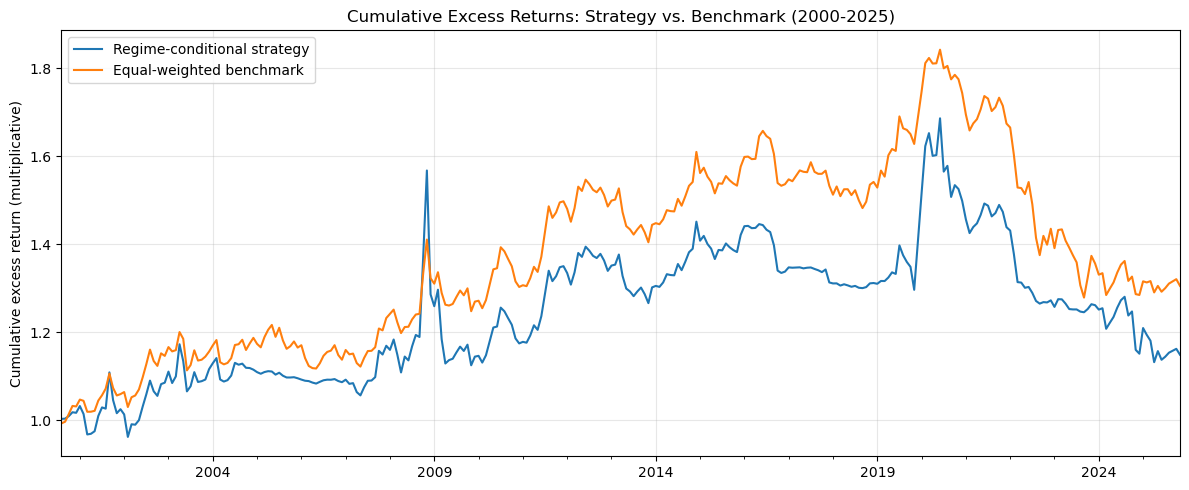

In [107]:
# --- Strategy and benchmark backtest ---

# Strategy weights by regime (committed in decisions.md)
strategy_weights = {
    'easing':     {'2Y': 0.0,  '5Y': 0.0,  '10Y': 0.0,  '30Y': 1.0},
    'neutral':    {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25},
    'tightening': {'2Y': 1.0,  '5Y': 0.0,  '10Y': 0.0,  '30Y': 0.0},
}

# Benchmark: equal-weighted (matches "neutral" weights)
benchmark_weights = {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25}

# Transaction cost: 1 bp per maturity rebalanced (proportional to weight change)
TC_BPS = 0.0001  # 1 basis point in decimal

# --- Build the backtest ---
bt = df[['regime', 'rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].dropna().copy()

# Use lagged regime to avoid look-ahead (regime at t-1 determines weights for t)
bt['regime_lag'] = bt['regime'].shift(1)
bt = bt.dropna(subset=['regime_lag'])

# Compute strategy weights and returns
strat_returns = []
strat_weights_history = []
prev_weights = np.array([0.25, 0.25, 0.25, 0.25])  # start at neutral

for date, row in bt.iterrows():
    regime = row['regime_lag']
    w = strategy_weights[regime]
    weights = np.array([w['2Y'], w['5Y'], w['10Y'], w['30Y']])
    
    # Transaction cost: sum of absolute weight changes × bps
    turnover = np.abs(weights - prev_weights).sum()
    tc = turnover * TC_BPS
    
    # Portfolio excess return this month
    rx = np.array([row['rx_2Y'], row['rx_5Y'], row['rx_10Y'], row['rx_30Y']])
    portfolio_rx = (weights * rx).sum() - tc
    
    strat_returns.append(portfolio_rx)
    strat_weights_history.append(weights)
    prev_weights = weights

bt['strat_rx'] = strat_returns

# Benchmark: equal-weighted, no rebalancing cost (since weights are constant)
bt['bench_rx'] = 0.25 * (bt['rx_2Y'] + bt['rx_5Y'] + bt['rx_10Y'] + bt['rx_30Y'])

# --- Performance metrics ---
def perf_metrics(returns, name):
    ann_mean = returns.mean() * 12 * 100
    ann_std = returns.std() * np.sqrt(12) * 100
    sharpe = ann_mean / ann_std if ann_std > 0 else 0
    
    # Max drawdown
    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min() * 100
    
    print(f"\n{name}:")
    print(f"  Annualized excess return: {ann_mean:>6.2f}%")
    print(f"  Annualized volatility:    {ann_std:>6.2f}%")
    print(f"  Sharpe ratio:             {sharpe:>6.2f}")
    print(f"  Max drawdown:             {max_dd:>6.2f}%")
    print(f"  Observations:             {len(returns)}")

perf_metrics(bt['strat_rx'], "STRATEGY (regime-conditional duration)")
perf_metrics(bt['bench_rx'], "BENCHMARK (equal-weighted static)")

# --- Cumulative returns plot ---
fig, ax = plt.subplots(figsize=(12, 5))
(1 + bt['strat_rx']).cumprod().plot(ax=ax, label='Regime-conditional strategy', linewidth=1.5)
(1 + bt['bench_rx']).cumprod().plot(ax=ax, label='Equal-weighted benchmark', linewidth=1.5)
ax.set_title('Cumulative Excess Returns: Strategy vs. Benchmark (2000-2025)')
ax.set_ylabel('Cumulative excess return (multiplicative)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()


STRATEGY V1 (extreme: 100/0):
  Annualized excess return:   0.98%
  Annualized volatility:      9.28%
  Sharpe ratio:               0.11
  Max drawdown:             -32.85%

STRATEGY V2 (moderate: 50/50):
  Annualized excess return:   1.20%
  Annualized volatility:      7.61%
  Sharpe ratio:               0.16
  Max drawdown:             -28.97%

BENCHMARK (equal-weighted static):
  Annualized excess return:   1.27%
  Annualized volatility:      6.65%
  Sharpe ratio:               0.19
  Max drawdown:             -30.57%


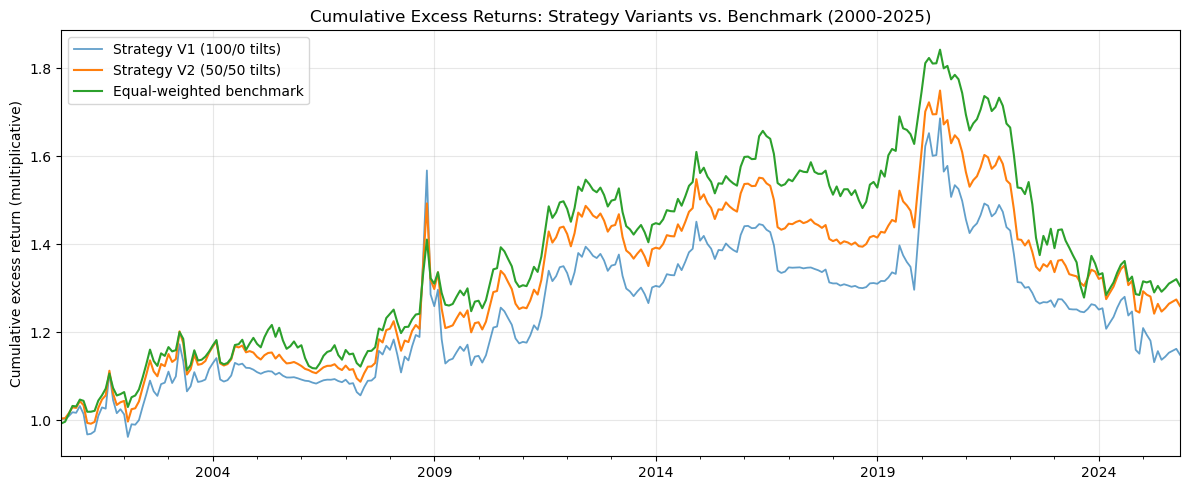

In [108]:
# --- Strategy V2: less concentrated (50/50 tilts instead of 100/0) ---

strategy_weights_v2 = {
    'easing':     {'2Y': 0.0,  '5Y': 0.0,  '10Y': 0.5, '30Y': 0.5},
    'neutral':    {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25},
    'tightening': {'2Y': 0.5,  '5Y': 0.5,  '10Y': 0.0, '30Y': 0.0},
}

# Transaction cost: 1 bp per maturity rebalanced
TC_BPS = 0.0001

# --- Build the backtest ---
bt2 = df[['regime', 'rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].dropna().copy()
bt2['regime_lag'] = bt2['regime'].shift(1)
bt2 = bt2.dropna(subset=['regime_lag'])

strat_returns_v2 = []
prev_weights = np.array([0.25, 0.25, 0.25, 0.25])

for date, row in bt2.iterrows():
    regime = row['regime_lag']
    w = strategy_weights_v2[regime]
    weights = np.array([w['2Y'], w['5Y'], w['10Y'], w['30Y']])
    
    turnover = np.abs(weights - prev_weights).sum()
    tc = turnover * TC_BPS
    
    rx = np.array([row['rx_2Y'], row['rx_5Y'], row['rx_10Y'], row['rx_30Y']])
    portfolio_rx = (weights * rx).sum() - tc
    
    strat_returns_v2.append(portfolio_rx)
    prev_weights = weights

bt2['strat_v2_rx'] = strat_returns_v2
bt2['bench_rx'] = 0.25 * (bt2['rx_2Y'] + bt2['rx_5Y'] + bt2['rx_10Y'] + bt2['rx_30Y'])

# Add V1 results for comparison
bt2['strat_v1_rx'] = bt['strat_rx'].values

# --- Performance metrics ---
def perf_metrics(returns, name):
    ann_mean = returns.mean() * 12 * 100
    ann_std = returns.std() * np.sqrt(12) * 100
    sharpe = ann_mean / ann_std if ann_std > 0 else 0
    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min() * 100
    
    print(f"\n{name}:")
    print(f"  Annualized excess return: {ann_mean:>6.2f}%")
    print(f"  Annualized volatility:    {ann_std:>6.2f}%")
    print(f"  Sharpe ratio:             {sharpe:>6.2f}")
    print(f"  Max drawdown:             {max_dd:>6.2f}%")

perf_metrics(bt2['strat_v1_rx'], "STRATEGY V1 (extreme: 100/0)")
perf_metrics(bt2['strat_v2_rx'], "STRATEGY V2 (moderate: 50/50)")
perf_metrics(bt2['bench_rx'],    "BENCHMARK (equal-weighted static)")

# --- Cumulative returns plot ---
fig, ax = plt.subplots(figsize=(12, 5))
(1 + bt2['strat_v1_rx']).cumprod().plot(ax=ax, label='Strategy V1 (100/0 tilts)', linewidth=1.3, alpha=0.7)
(1 + bt2['strat_v2_rx']).cumprod().plot(ax=ax, label='Strategy V2 (50/50 tilts)', linewidth=1.5)
(1 + bt2['bench_rx']).cumprod().plot(ax=ax, label='Equal-weighted benchmark', linewidth=1.5)
ax.set_title('Cumulative Excess Returns: Strategy Variants vs. Benchmark (2000-2025)')
ax.set_ylabel('Cumulative excess return (multiplicative)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/cumulative_returns_v2.png', dpi=150, bbox_inches='tight')
plt.show()

Slope signal distribution:
slope_signal
steep     192
normal     64
flat       56
Name: count, dtype: int64

Fraction:
slope_signal
steep     0.615385
normal    0.205128
flat      0.179487
Name: proportion, dtype: float64

STRATEGY (slope-based carry):
  Annualized excess return:   2.33%
  Annualized volatility:      9.25%
  Sharpe ratio:               0.25
  Max drawdown:             -29.70%

BENCHMARK (equal-weighted static):
  Annualized excess return:   1.40%
  Annualized volatility:      6.61%
  Sharpe ratio:               0.21
  Max drawdown:             -30.57%


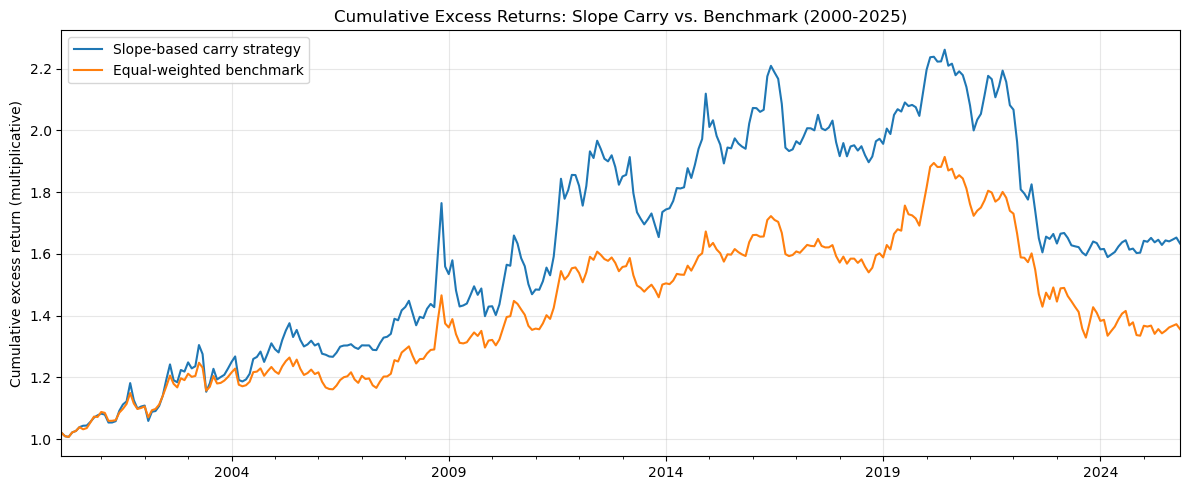

In [109]:
# --- Option 1: Slope-based carry strategy ---

# The signal: yield curve slope (10Y - 3M)
# Idea: when slope is steep, expected bond returns are high (carry + roll-down)
#       → tilt to long duration
#       when slope is flat/inverted, expected returns are low → tilt short duration

# Use a fixed threshold: 100 bps is a reasonable historical median
SLOPE_THRESHOLD_HIGH = 0.0100   # 100 bps: above this = "steep curve"
SLOPE_THRESHOLD_LOW  = 0.0000   # 0 bps: below this = "flat/inverted"

def classify_slope(s):
    if pd.isna(s):
        return np.nan
    elif s > SLOPE_THRESHOLD_HIGH:
        return 'steep'
    elif s < SLOPE_THRESHOLD_LOW:
        return 'flat'
    else:
        return 'normal'

df['slope_signal'] = df['S'].apply(classify_slope)

print("Slope signal distribution:")
print(df['slope_signal'].value_counts())
print("\nFraction:")
print(df['slope_signal'].value_counts(normalize=True))

# --- Strategy weights based on slope ---
# Steep curve → long duration (high carry, expect rates to fall or curve to flatten)
# Flat/inverted → short duration (low carry, expect rates to rise or curve to steepen)
# Normal → equal-weighted

slope_strategy_weights = {
    'steep':  {'2Y': 0.0,  '5Y': 0.0,  '10Y': 0.5, '30Y': 0.5},
    'normal': {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25},
    'flat':   {'2Y': 0.5,  '5Y': 0.5,  '10Y': 0.0, '30Y': 0.0},
}

# --- Backtest ---
TC_BPS = 0.0001

bt3 = df[['slope_signal', 'rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].dropna().copy()
bt3['signal_lag'] = bt3['slope_signal'].shift(1)
bt3 = bt3.dropna(subset=['signal_lag'])

slope_returns = []
prev_weights = np.array([0.25, 0.25, 0.25, 0.25])

for date, row in bt3.iterrows():
    signal = row['signal_lag']
    w = slope_strategy_weights[signal]
    weights = np.array([w['2Y'], w['5Y'], w['10Y'], w['30Y']])
    
    turnover = np.abs(weights - prev_weights).sum()
    tc = turnover * TC_BPS
    
    rx = np.array([row['rx_2Y'], row['rx_5Y'], row['rx_10Y'], row['rx_30Y']])
    portfolio_rx = (weights * rx).sum() - tc
    
    slope_returns.append(portfolio_rx)
    prev_weights = weights

bt3['slope_strat_rx'] = slope_returns
bt3['bench_rx'] = 0.25 * (bt3['rx_2Y'] + bt3['rx_5Y'] + bt3['rx_10Y'] + bt3['rx_30Y'])

# --- Performance ---
def perf_metrics(returns, name):
    ann_mean = returns.mean() * 12 * 100
    ann_std = returns.std() * np.sqrt(12) * 100
    sharpe = ann_mean / ann_std if ann_std > 0 else 0
    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min() * 100
    
    print(f"\n{name}:")
    print(f"  Annualized excess return: {ann_mean:>6.2f}%")
    print(f"  Annualized volatility:    {ann_std:>6.2f}%")
    print(f"  Sharpe ratio:             {sharpe:>6.2f}")
    print(f"  Max drawdown:             {max_dd:>6.2f}%")

perf_metrics(bt3['slope_strat_rx'], "STRATEGY (slope-based carry)")
perf_metrics(bt3['bench_rx'],       "BENCHMARK (equal-weighted static)")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
(1 + bt3['slope_strat_rx']).cumprod().plot(ax=ax, label='Slope-based carry strategy', linewidth=1.5)
(1 + bt3['bench_rx']).cumprod().plot(ax=ax, label='Equal-weighted benchmark', linewidth=1.5)
ax.set_title('Cumulative Excess Returns: Slope Carry vs. Benchmark (2000-2025)')
ax.set_ylabel('Cumulative excess return (multiplicative)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


STRATEGY: Slope only:
  Annualized excess return:   2.22%
  Annualized volatility:      9.32%
  Sharpe ratio:               0.24
  Max drawdown:             -29.70%

STRATEGY: Slope + regime filter:
  Annualized excess return:   1.85%
  Annualized volatility:      9.20%
  Sharpe ratio:               0.20
  Max drawdown:             -30.38%

BENCHMARK:
  Annualized excess return:   1.27%
  Annualized volatility:      6.65%
  Sharpe ratio:               0.19
  Max drawdown:             -30.57%


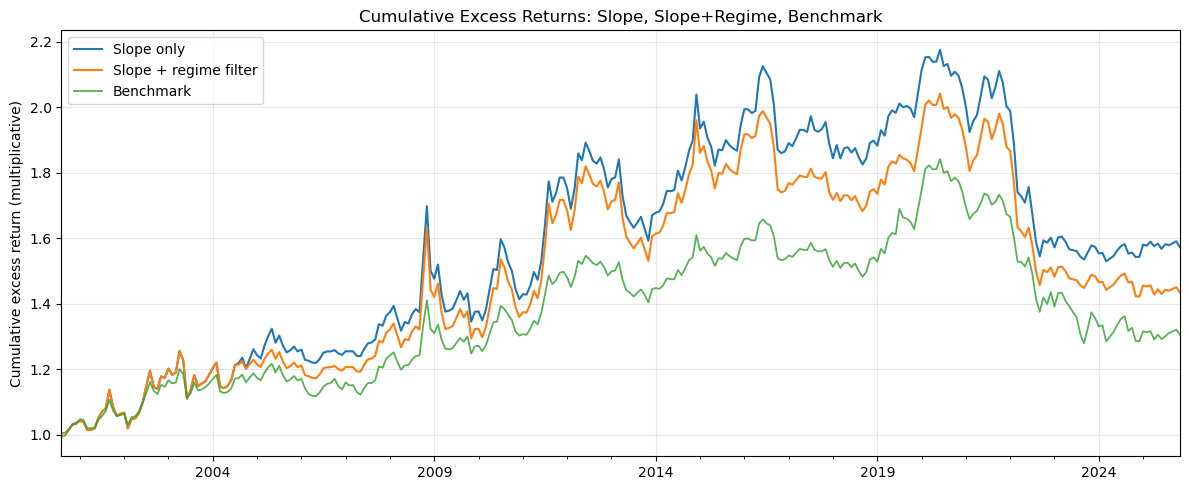

In [110]:
# --- Combined: slope carry + regime conditioning ---
# Idea: trust the slope signal MORE during easing regimes (Fed cutting confirms steep curve signal)
# and LESS during tightening regimes (Fed hiking contradicts steep curve signal)

# Construct a combined dataset
combined = df[['slope_signal', 'regime', 'rx_2Y', 'rx_5Y', 'rx_10Y', 'rx_30Y']].dropna().copy()
combined['signal_lag'] = combined['slope_signal'].shift(1)
combined['regime_lag'] = combined['regime'].shift(1)
combined = combined.dropna()

# Strategy: condition on BOTH slope and regime
# Default: use slope signal weights (same as Option 1)
# Override: if regime contradicts slope, go to neutral

def get_combined_weights(slope_sig, regime):
    # If slope says steep but Fed is tightening → contradicting signals → go neutral
    if slope_sig == 'steep' and regime == 'tightening':
        return {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25}
    # If slope says flat but Fed is easing → contradicting → go neutral
    elif slope_sig == 'flat' and regime == 'easing':
        return {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25}
    # Otherwise: trust the slope signal
    else:
        return slope_strategy_weights[slope_sig]

combined_returns = []
prev_weights = np.array([0.25, 0.25, 0.25, 0.25])

for date, row in combined.iterrows():
    w = get_combined_weights(row['signal_lag'], row['regime_lag'])
    weights = np.array([w['2Y'], w['5Y'], w['10Y'], w['30Y']])
    
    turnover = np.abs(weights - prev_weights).sum()
    tc = turnover * TC_BPS
    
    rx = np.array([row['rx_2Y'], row['rx_5Y'], row['rx_10Y'], row['rx_30Y']])
    portfolio_rx = (weights * rx).sum() - tc
    
    combined_returns.append(portfolio_rx)
    prev_weights = weights

combined['combined_rx'] = combined_returns
combined['slope_only_rx'] = bt3['slope_strat_rx'].reindex(combined.index)
combined['bench_rx'] = 0.25 * (combined['rx_2Y'] + combined['rx_5Y'] + combined['rx_10Y'] + combined['rx_30Y'])

# --- Performance ---
perf_metrics(combined['slope_only_rx'].dropna(), "STRATEGY: Slope only")
perf_metrics(combined['combined_rx'].dropna(),   "STRATEGY: Slope + regime filter")
perf_metrics(combined['bench_rx'].dropna(),      "BENCHMARK")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
(1 + combined['slope_only_rx'].dropna()).cumprod().plot(ax=ax, label='Slope only', linewidth=1.5)
(1 + combined['combined_rx'].dropna()).cumprod().plot(ax=ax, label='Slope + regime filter', linewidth=1.5)
(1 + combined['bench_rx'].dropna()).cumprod().plot(ax=ax, label='Benchmark', linewidth=1.3, alpha=0.8)
ax.set_title('Cumulative Excess Returns: Slope, Slope+Regime, Benchmark')
ax.set_ylabel('Cumulative excess return (multiplicative)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [111]:


# --- Build VAR dataset ---
# Use NS proxies + FFR. All in decimal form already.
# Drop the lookback NaN rows from regime classifier (we don't use regime here, but keep sample aligned)

var_data = df[['L', 'S', 'C', 'FFR']].dropna().copy()
print(f"VAR sample: {len(var_data)} observations from {var_data.index.min().date()} to {var_data.index.max().date()}")
print(f"\nMeans:")
print(var_data.mean().round(4))
print(f"\nStd devs:")
print(var_data.std().round(4))

# --- Estimate VAR with lag selection ---
model = VAR(var_data)

# Lag selection via information criteria
print("\nLag selection:")
selection = model.select_order(maxlags=12)
print(selection.summary())

# Use BIC-selected lag length (more parsimonious than AIC for sample size)
optimal_lag = selection.bic
if optimal_lag == 0:
    optimal_lag = 1  # need at least 1 lag
print(f"\nUsing BIC-selected lag length: {optimal_lag}")

# --- Fit the VAR ---
var_results = model.fit(optimal_lag)
print(var_results.summary())

VAR sample: 312 observations from 2000-01-31 to 2025-12-31

Means:
L      0.0330
S      0.0136
C     -0.0075
FFR    0.0201
dtype: float64

Std devs:
L      0.0130
S      0.0134
C      0.0082
FFR    0.0203
dtype: float64

Lag selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -39.36      -39.31   8.052e-18      -39.34
1       -50.43      -50.18   1.255e-22      -50.33
2       -50.89     -50.45*   7.922e-23     -50.71*
3       -50.88      -50.24   8.021e-23      -50.62
4      -50.91*      -50.07  7.782e-23*      -50.57
5       -50.87      -49.83   8.074e-23      -50.46
6       -50.89      -49.65   7.943e-23      -50.39
7       -50.85      -49.41   8.298e-23      -50.27
8       -50.86      -49.23   8.227e-23      -50.20
9       -50.80      -48.97   8.715e-23      -50.07
10      -50.75      -48.73   9.148e-23      -49.94
11      -50.68      -48.46   9.832e-23      -49.79

In [112]:
def perf_row(returns):
    returns = returns.dropna()
    ann_mean = returns.mean() * 12 * 100
    ann_std = returns.std() * np.sqrt(12) * 100
    sharpe = ann_mean / ann_std if ann_std > 0 else np.nan

    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min() * 100

    return [
        round(ann_mean, 2),
        round(ann_std, 2),
        round(sharpe, 2),
        round(max_dd, 2)
    ]

In [113]:
IRF_HORIZON = 12
HORIZON_INDEX = 11
variables = ['Level', 'Slope', 'Curvature', 'FFR']

# --- Variance decomposition ---
fevd = var_results.fevd(IRF_HORIZON)

print("\nVariance decomposition at 12-month horizon:")
print("(Share of forecast error variance attributable to each shock)")
print("="*60)

for i, target in enumerate(variables):
    print(f"\n{target} forecast error variance:")
    for j, shock in enumerate(variables):
        share = fevd.decomp[i, HORIZON_INDEX, j] * 100
        print(f"  Share from {shock} shock: {share:>5.1f}%")


Variance decomposition at 12-month horizon:
(Share of forecast error variance attributable to each shock)

Level forecast error variance:
  Share from Level shock:  96.4%
  Share from Slope shock:   2.6%
  Share from Curvature shock:   0.8%
  Share from FFR shock:   0.2%

Slope forecast error variance:
  Share from Level shock:  19.1%
  Share from Slope shock:  44.9%
  Share from Curvature shock:  28.9%
  Share from FFR shock:   7.1%

Curvature forecast error variance:
  Share from Level shock:   2.6%
  Share from Slope shock:   0.4%
  Share from Curvature shock:  96.4%
  Share from FFR shock:   0.6%

FFR forecast error variance:
  Share from Level shock:  23.3%
  Share from Slope shock:  44.8%
  Share from Curvature shock:  26.8%
  Share from FFR shock:   5.1%


In [114]:
print("Summary statistics (yields in %):")
summary = df[['y_3M', 'y_2Y', 'y_5Y', 'y_10Y', 'y_30Y', 'FFR']].describe()
summary = summary.loc[['mean', 'std', 'min', 'max']] * 100
print(summary.round(2))

Summary statistics (yields in %):
      y_3M  y_2Y  y_5Y  y_10Y  y_30Y   FFR
mean  1.94  2.24  2.75   3.30   3.89  2.01
std   2.00  1.76  1.49   1.30   1.17  2.03
min   0.00  0.11  0.21   0.55   1.20  0.05
max   6.38  6.69  6.71   6.68   6.49  6.54


In [115]:
# ============================================================
# RESULTS 4.1 — TABLES
# ============================================================

# --- Table 1: Excess returns by regime (descriptive) ---
print("="*70)
print("TABLE 1 — Excess returns by regime")
print("="*70)

table1 = pd.DataFrame(index=['easing', 'neutral', 'tightening'],
                     columns=pd.MultiIndex.from_product(
                         [['2Y', '5Y', '10Y', '30Y'],
                          ['Mean', 'Std', 'Sharpe', 'N']]))

for regime in ['easing', 'neutral', 'tightening']:
    for mat in ['2Y', '5Y', '10Y', '30Y']:
        sub = df.loc[df['regime'] == regime, f'rx_{mat}'].dropna()
        ann_mean = sub.mean() * 12 * 100
        ann_std = sub.std() * np.sqrt(12) * 100
        sharpe = ann_mean / ann_std if ann_std > 0 else 0
        n = len(sub)
        table1.loc[regime, (mat, 'Mean')] = round(ann_mean, 2)
        table1.loc[regime, (mat, 'Std')] = round(ann_std, 2)
        table1.loc[regime, (mat, 'Sharpe')] = round(sharpe, 2)
        table1.loc[regime, (mat, 'N')] = n

print(table1.to_string())

# --- Table 2: Regression coefficients (baseline + combined, all 4 maturities) ---
print("\n" + "="*70)
print("TABLE 2 — Predictive regressions: baseline and combined specifications")
print("="*70)

# We need to format coefficients with significance stars and standard errors
def format_coef(coef, pval):
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    return f"{coef:.4f}{sig}"

# Variable names in the order we want them displayed
baseline_vars = ['const', 'L', 'S', 'C']
combined_vars = (['const', 'L', 'S', 'C'] +
                 ['regime_easing', 'regime_tightening'] +
                 ['L_x_easing', 'L_x_tightening',
                  'S_x_easing', 'S_x_tightening',
                  'C_x_easing', 'C_x_tightening'])

# Pretty names for display
pretty_names = {
    'const': 'Constant',
    'L': 'Level',
    'S': 'Slope',
    'C': 'Curvature',
    'regime_easing': 'D_easing',
    'regime_tightening': 'D_tightening',
    'L_x_easing': 'Level × D_easing',
    'L_x_tightening': 'Level × D_tightening',
    'S_x_easing': 'Slope × D_easing',
    'S_x_tightening': 'Slope × D_tightening',
    'C_x_easing': 'Curvature × D_easing',
    'C_x_tightening': 'Curvature × D_tightening',
}

# Build the combined display table
print("\nBaseline specification (NS proxies only):")
baseline_table = pd.DataFrame(index=[pretty_names[v] for v in baseline_vars],
                              columns=['2Y', '5Y', '10Y', '30Y'])
baseline_r2 = {}
for mat in ['2Y', '5Y', '10Y', '30Y']:
    m = baseline_results[mat]
    for var, coef, pval in zip(['const'] + ['L', 'S', 'C'], m.params, m.pvalues):
        baseline_table.loc[pretty_names[var], mat] = format_coef(coef, pval)
    baseline_r2[mat] = m.rsquared

# Add R² and N
r2_row = pd.DataFrame([[f"{baseline_r2[m]:.3f}" for m in ['2Y', '5Y', '10Y', '30Y']]],
                     index=['R²'], columns=['2Y', '5Y', '10Y', '30Y'])
baseline_table = pd.concat([baseline_table, r2_row])
print(baseline_table.to_string())

print("\nCombined specification (NS proxies + regime + interactions):")
combined_table = pd.DataFrame(index=[pretty_names[v] for v in combined_vars],
                              columns=['2Y', '5Y', '10Y', '30Y'])
combined_r2 = {}
combined_f = {}
combined_fp = {}
for mat in ['2Y', '5Y', '10Y', '30Y']:
    m = regime_results[mat]
    coef_names = ['const'] + interaction_X
    for var, coef, pval in zip(coef_names, m.params, m.pvalues):
        if var in pretty_names:
            combined_table.loc[pretty_names[var], mat] = format_coef(coef, pval)
    combined_r2[mat] = m.rsquared
    
    # Joint F-test
    regime_vars = [v for v in interaction_X if 'regime' in v or '_x_' in v]
    f_test = m.f_test(' = '.join(regime_vars) + ' = 0')
    combined_f[mat] = float(f_test.fvalue)
    combined_fp[mat] = float(f_test.pvalue)

# Add R², F-stat, p-value, N
extra_rows = pd.DataFrame({
    '2Y': [f"{combined_r2['2Y']:.3f}", f"{combined_f['2Y']:.2f}", f"{combined_fp['2Y']:.3f}"],
    '5Y': [f"{combined_r2['5Y']:.3f}", f"{combined_f['5Y']:.2f}", f"{combined_fp['5Y']:.3f}"],
    '10Y': [f"{combined_r2['10Y']:.3f}", f"{combined_f['10Y']:.2f}", f"{combined_fp['10Y']:.3f}"],
    '30Y': [f"{combined_r2['30Y']:.3f}", f"{combined_f['30Y']:.2f}", f"{combined_fp['30Y']:.3f}"],
}, index=['R²', 'F-stat (regime terms)', 'p-value (regime terms)'])

combined_table = pd.concat([combined_table, extra_rows])
print(combined_table.to_string())

# --- Table 3: Sample size (single number, useful as note) ---
print(f"\nN = 305 observations for all regressions")
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")
print("Newey-West HAC standard errors (3 lags)")

TABLE 1 — Excess returns by regime
              2Y                      5Y                     10Y                     30Y                   
            Mean   Std Sharpe    N  Mean   Std Sharpe    N  Mean   Std Sharpe    N  Mean    Std Sharpe    N
easing      2.81   2.0   1.41   68  4.84  4.76   1.02   68  5.53  8.58   0.64   68  3.92  17.16   0.23   68
neutral     0.19  1.42   0.14  156  0.54  4.25   0.13  156  1.28  7.42   0.17  156  2.18  13.98   0.16  156
tightening -0.88  1.54  -0.57   81 -0.68  3.99  -0.17   81 -0.44  6.91  -0.06   81 -0.62  13.05  -0.05   81

TABLE 2 — Predictive regressions: baseline and combined specifications

Baseline specification (NS proxies only):
                  2Y         5Y        10Y        30Y
Constant   -0.0025**  -0.0064**  -0.0107**  -0.0185**
Level      0.0737***  0.1766***  0.2650***   0.3877**
Slope         0.0085     0.0962     0.1736     0.2437
Curvature    -0.0473    -0.0378    -0.1483    -0.5141
R²             0.041      0.039      0.0

In [116]:
# Recompute Table 4 with the aligned sample (matches Table 5)
print("="*60)
print("TABLE 4 — Strategy performance vs. benchmark (aligned sample)")
print("="*60)

table4 = pd.DataFrame({
    'Slope-based strategy': perf_row(combined['slope_only_rx'].dropna()),
    'Equal-weighted benchmark': perf_row(combined['bench_rx'].dropna()),
}, index=['Annualized excess return (%)', 'Annualized volatility (%)',
         'Sharpe ratio', 'Maximum drawdown (%)'])

print(table4.to_string())

TABLE 4 — Strategy performance vs. benchmark (aligned sample)
                              Slope-based strategy  Equal-weighted benchmark
Annualized excess return (%)                  2.22                      1.27
Annualized volatility (%)                     9.32                      6.65
Sharpe ratio                                  0.24                      0.19
Maximum drawdown (%)                        -29.70                    -30.57


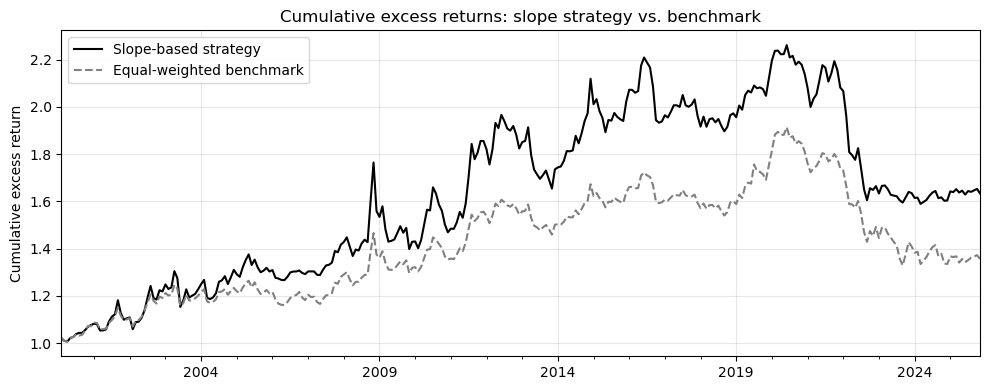

In [117]:
fig, ax = plt.subplots(figsize=(10, 4))
(1 + bt3['slope_strat_rx']).cumprod().plot(ax=ax, label='Slope-based strategy', linewidth=1.5, color='black')
(1 + bt3['bench_rx']).cumprod().plot(ax=ax, label='Equal-weighted benchmark', linewidth=1.5, color='gray', linestyle='--')
ax.set_title('Cumulative excess returns: slope strategy vs. benchmark')
ax.set_ylabel('Cumulative excess return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/slope_vs_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

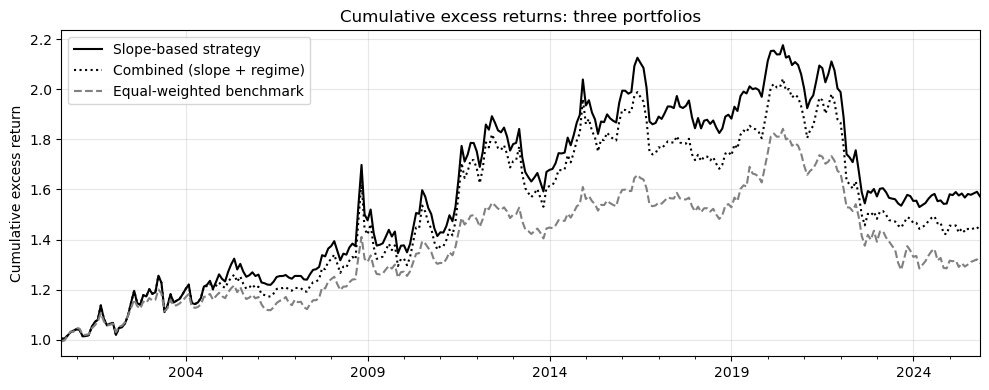

In [118]:
fig, ax = plt.subplots(figsize=(10, 4))
(1 + combined['slope_only_rx'].dropna()).cumprod().plot(ax=ax, label='Slope-based strategy', linewidth=1.5, color='black')
(1 + combined['combined_rx'].dropna()).cumprod().plot(ax=ax, label='Combined (slope + regime)', linewidth=1.5, color='black', linestyle=':')
(1 + combined['bench_rx'].dropna()).cumprod().plot(ax=ax, label='Equal-weighted benchmark', linewidth=1.5, color='gray', linestyle='--')
ax.set_title('Cumulative excess returns: three portfolios')
ax.set_ylabel('Cumulative excess return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/three_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
print("="*60)
print("TABLE 6 — Variance decomposition at 12-month horizon")
print("="*60)

vd_table = pd.DataFrame(
    index=['Level', 'Slope', 'Curvature', 'FFR'],
    columns=['Level shock', 'Slope shock', 'Curvature shock', 'FFR shock']
)

for i, target in enumerate(variables):
    for j, shock in enumerate(variables):
        share = fevd.decomp[i, HORIZON_INDEX, j] * 100
        vd_table.iloc[i, j] = round(share, 1)

print(vd_table.to_string())
print("\nValues are percentages of forecast error variance at the 12-month horizon.")

TABLE 6 — Variance decomposition at 12-month horizon
          Level shock Slope shock Curvature shock FFR shock
Level            96.4         2.6             0.8       0.2
Slope            19.1        44.9            28.9       7.1
Curvature         2.6         0.4            96.4       0.6
FFR              23.3        44.8            26.8       5.1

Values are percentages of forecast error variance at the 12-month horizon.


In [120]:
# Recompute regime-only strategy on the same aligned sample as Table 5
strategy_weights_v1 = {
    'easing':     {'2Y': 0.0,  '5Y': 0.0,  '10Y': 0.0, '30Y': 1.0},
    'neutral':    {'2Y': 0.25, '5Y': 0.25, '10Y': 0.25, '30Y': 0.25},
    'tightening': {'2Y': 1.0,  '5Y': 0.0,  '10Y': 0.0, '30Y': 0.0},
}

regime_only_returns = []
prev_weights = np.array([0.25, 0.25, 0.25, 0.25])

for date, row in combined.iterrows():
    regime = row['regime_lag']
    w = strategy_weights_v1[regime]
    weights = np.array([w['2Y'], w['5Y'], w['10Y'], w['30Y']])
    
    turnover = np.abs(weights - prev_weights).sum()
    tc = turnover * 0.0001
    
    rx = np.array([row['rx_2Y'], row['rx_5Y'], row['rx_10Y'], row['rx_30Y']])
    portfolio_rx = (weights * rx).sum() - tc
    
    regime_only_returns.append(portfolio_rx)
    prev_weights = weights

combined['regime_only_rx'] = regime_only_returns

# Build the four-strategy table
print("="*80)
print("TABLE 5 — Four-strategy comparison")
print("="*80)

table5 = pd.DataFrame({
    'Regime-only strategy': perf_row(combined['regime_only_rx'].dropna()),
    'Slope-based strategy': perf_row(combined['slope_only_rx'].dropna()),
    'Combined (slope + regime)': perf_row(combined['combined_rx'].dropna()),
    'Equal-weighted benchmark': perf_row(combined['bench_rx'].dropna()),
}, index=['Annualized excess return (%)', 'Annualized volatility (%)',
         'Sharpe ratio', 'Maximum drawdown (%)'])

print(table5.to_string())

TABLE 5 — Four-strategy comparison
                              Regime-only strategy  Slope-based strategy  Combined (slope + regime)  Equal-weighted benchmark
Annualized excess return (%)                  0.98                  2.22                       1.85                      1.27
Annualized volatility (%)                     9.28                  9.32                       9.20                      6.65
Sharpe ratio                                  0.11                  0.24                       0.20                      0.19
Maximum drawdown (%)                        -32.85                -29.70                     -30.38                    -30.57
